# Topic Dataset Cleaning and Balancing Pipeline

Pipeline:

1 Load all CSV files from folder  
2 Combine into one dataframe  
3 Filter sentences where:
   - max topic ≥ 0.41
   - gap between top2 topics ≥ 0.2  
4 Detect dominant topic  
5 Extract year + month  
6 Balance topic counts per month  
7 Ensure max difference between topics ≤ 500  
8 Remove weakest sentences from dominant topic  
9 Plot topic distribution  
10 Plot month × year heatmaps


In [1]:

import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns


## Load All CSV Files

In [2]:

DATA_FOLDER = "/kaggle/input/datasets/prateek1005/topic-labbeled-w5"

files = glob.glob(os.path.join(DATA_FOLDER,"*.csv"))

print("Files found:",len(files))

dfs=[]

for f in files:
    print("Loading:",f)
    df=pd.read_csv(f)
    dfs.append(df)

data=pd.concat(dfs,ignore_index=True)

print("Total rows:",len(data))

data.head()


Files found: 5
Loading: /kaggle/input/datasets/prateek1005/topic-labbeled-w5/Climate.csv
Loading: /kaggle/input/datasets/prateek1005/topic-labbeled-w5/Technology.csv
Loading: /kaggle/input/datasets/prateek1005/topic-labbeled-w5/Economics.csv
Loading: /kaggle/input/datasets/prateek1005/topic-labbeled-w5/Health.csv
Loading: /kaggle/input/datasets/prateek1005/topic-labbeled-w5/War.csv
Total rows: 1146077


,date,sentence_id,main_sentence,w5_embedding,War,Health,Technology,Climate,Economics
0,2011-09-20 19:55:07,f1_a47_s2,"""The seven, members of a so-called ""major risk...","-0.016366452,0.12162542,-0.006107007,0.0451595...",0.249266,0.274897,0.187701,0.301356,0.200209
1,2011-09-21 13:59:11,f1_a50_s1,Story highlightsUrsula Sladek created Germany'...,"-0.02180171,0.017887823,0.010610466,0.04336527...",0.180741,0.126097,0.217226,0.444158,0.151267
2,2011-09-21 13:59:11,f1_a50_s2,"Founded by Sladek and a few friends in 1991, E...","-0.014108692,0.028728502,0.00976162,0.04034066...",0.210083,0.157591,0.219570,0.469669,0.150573
3,2011-09-21 13:59:11,f1_a50_s3,"Not bad for a self-professed housewife, who wr...","-0.0099581005,0.030005964,0.00935868,0.0392172...",0.211802,0.169906,0.216497,0.472940,0.148674
4,2011-09-21 13:59:11,f1_a50_s4,"Although her home in Schonau was over 2,000 ki...","-0.010584806,0.027590413,0.008503966,0.0383559...",0.187955,0.146839,0.200888,0.361376,0.083704


## Topic Columns

In [3]:

topics=["War","Economics","Climate","Technology","Health"]


In [4]:
# check size before
print("Rows before:", len(data))

# remove duplicates
data = data.drop_duplicates(
    subset=["date", "w5_embedding", "main_sentence"]
)

# check size after
print("Rows after:", len(data))

Rows before: 1146077
Rows after: 936612


## Compute Max Topic + Gap

In [5]:

data["max_topic_weight"]=data[topics].max(axis=1)

data["second_topic_weight"]=np.partition(
    data[topics].values,-2,axis=1
)[:,-2]

data["topic_gap"]=data["max_topic_weight"]-data["second_topic_weight"]


## Filter Strong Sentences

In [6]:

filtered=data[
    (data["max_topic_weight"]>=0.35) &
    (data["topic_gap"]>=0.2)
].copy()

print("Rows after filtering:",len(filtered))


Rows after filtering: 397402


## Dominant Topic

In [7]:

filtered["dominant_topic"]=filtered[topics].idxmax(axis=1)


## Extract Time

In [8]:

filtered["date"]=pd.to_datetime(filtered["date"],errors="coerce")

filtered["year"]=filtered["date"].dt.year
filtered["month"]=filtered["date"].dt.month
filtered["year_month"]=filtered["date"].dt.to_period("M")


## Balance Topics Per Month

In [9]:
import pandas as pd

MONTH_THRESHOLD = 600
YEAR_THRESHOLD = 3000

topics = ["War","Economics","Climate","Technology","Health"]

def iterative_balance(df, threshold):

    df = df.copy()

    while True:

        topic_counts = df["dominant_topic"].value_counts()

        if len(topic_counts) <= 1:
            break

        min_count = topic_counts.min()
        max_topic = topic_counts.idxmax()
        max_count = topic_counts.max()

        if (max_count - min_count) <= threshold:
            break

        # number of rows to remove
        remove_n = (max_count - min_count) - threshold

        tdf = df[df["dominant_topic"] == max_topic]

        # remove weakest sentences
        remove_rows = (
            tdf
            .sort_values(max_topic, ascending=True)
            .head(remove_n)
            .index
        )

        df = df.drop(remove_rows)

    return df

month_balanced = []

for ym, mdf in filtered.groupby("year_month"):

    balanced_month = iterative_balance(
        mdf,
        MONTH_THRESHOLD
    )

    month_balanced.append(balanced_month)

month_balanced = pd.concat(month_balanced)

print("After month balancing:", len(month_balanced))

year_balanced = []

for year, ydf in month_balanced.groupby("year"):

    balanced_year = iterative_balance(
        ydf,
        YEAR_THRESHOLD
    )

    year_balanced.append(balanced_year)

balanced = pd.concat(year_balanced)

print("Final balanced rows:", len(balanced))

After month balancing: 98925
Final balanced rows: 82018


dominant_topic
Climate       16117
Economics      4145
Health        17323
Technology     9592
War           34841
Name: count, dtype: int64


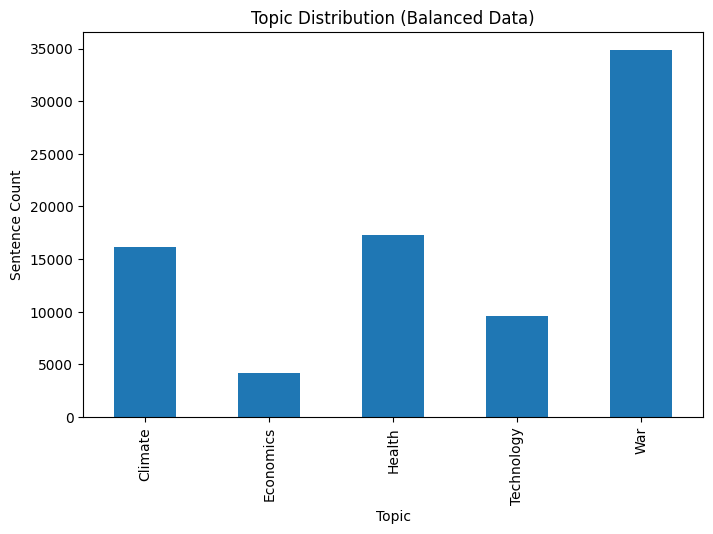

In [10]:
import matplotlib.pyplot as plt

# count sentences per topic
topic_counts = balanced["dominant_topic"].value_counts().sort_index()

print(topic_counts)

# plot
plt.figure(figsize=(8,5))

topic_counts.plot(
    kind="bar"
)

plt.title("Topic Distribution (Balanced Data)")
plt.xlabel("Topic")
plt.ylabel("Sentence Count")

plt.show()

## Topic Distribution by Year

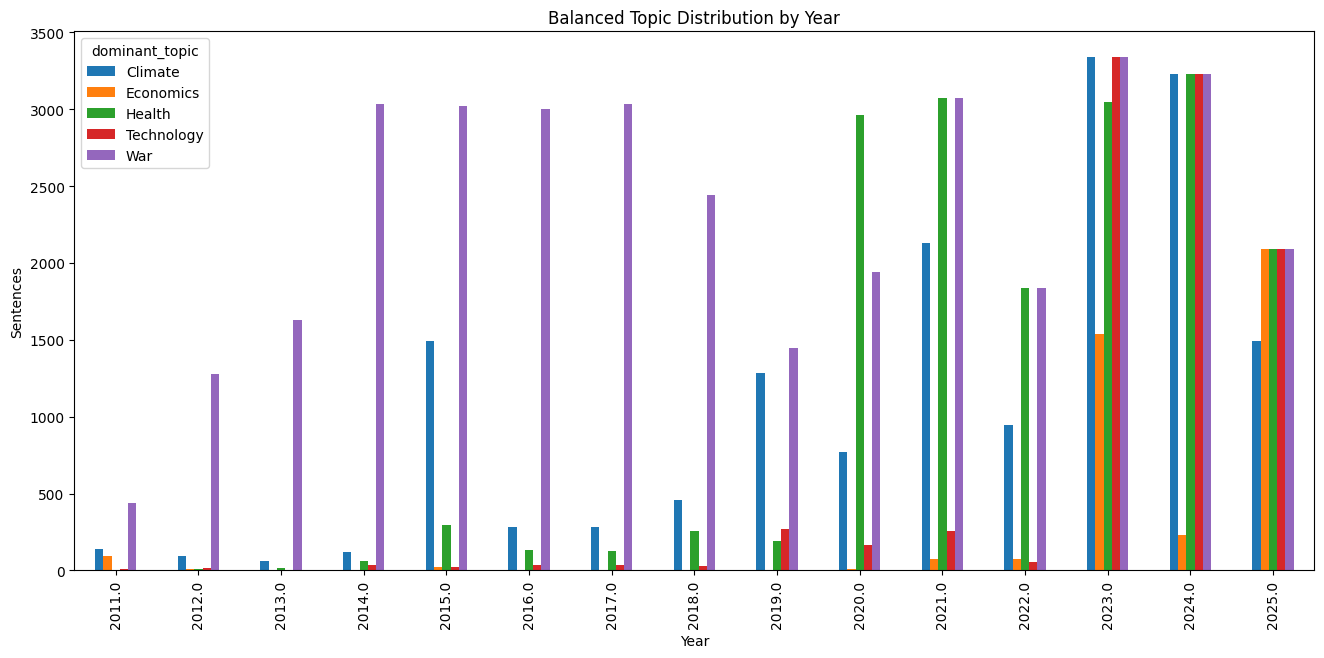

In [11]:

topic_year=(
    balanced.groupby(["year","dominant_topic"])
    .size()
    .unstack()
    .fillna(0)
)

topic_year.plot(kind="bar",figsize=(16,7))

plt.title("Balanced Topic Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Sentences")

plt.show()


## Month × Year Heatmap

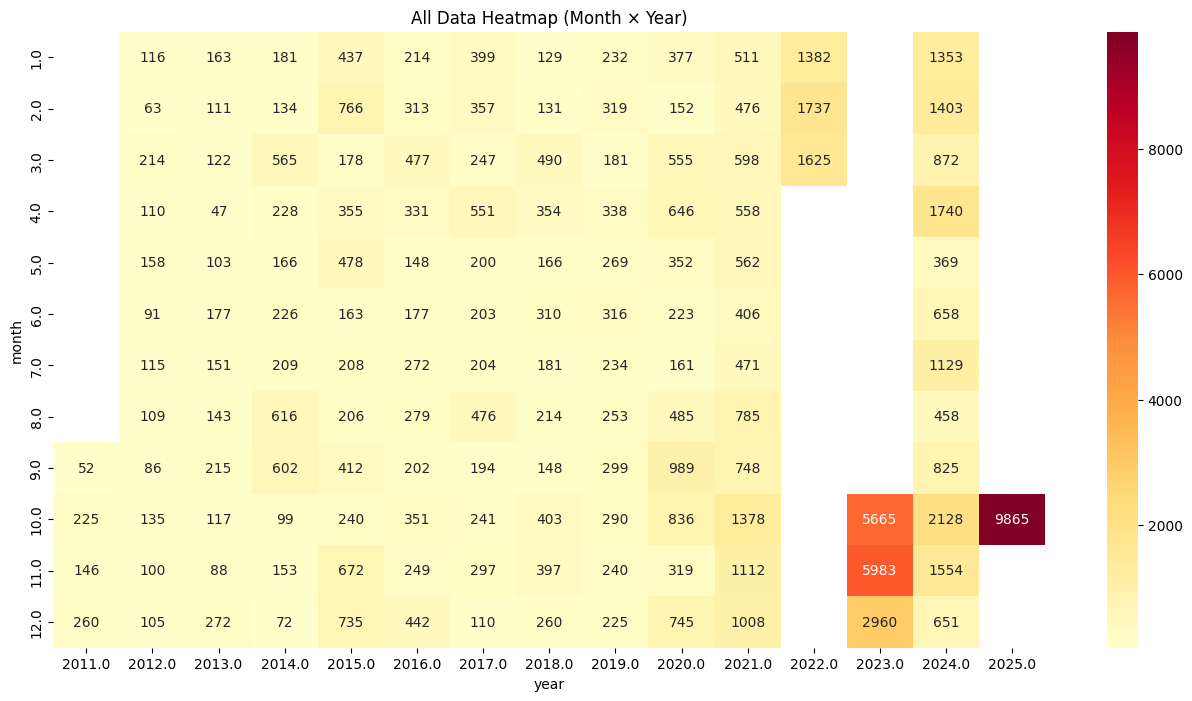

In [43]:

pivot=(
    balanced.groupby(["year","month"])
    .size()
    .reset_index()
    .pivot(index="month",columns="year",values=0)
)

plt.figure(figsize=(16,8)) 

sns.heatmap(pivot,annot=True,fmt=".0f",cmap="YlOrRd")

plt.title("All Data Heatmap (Month × Year)")

plt.show()


## Topic Heatmaps

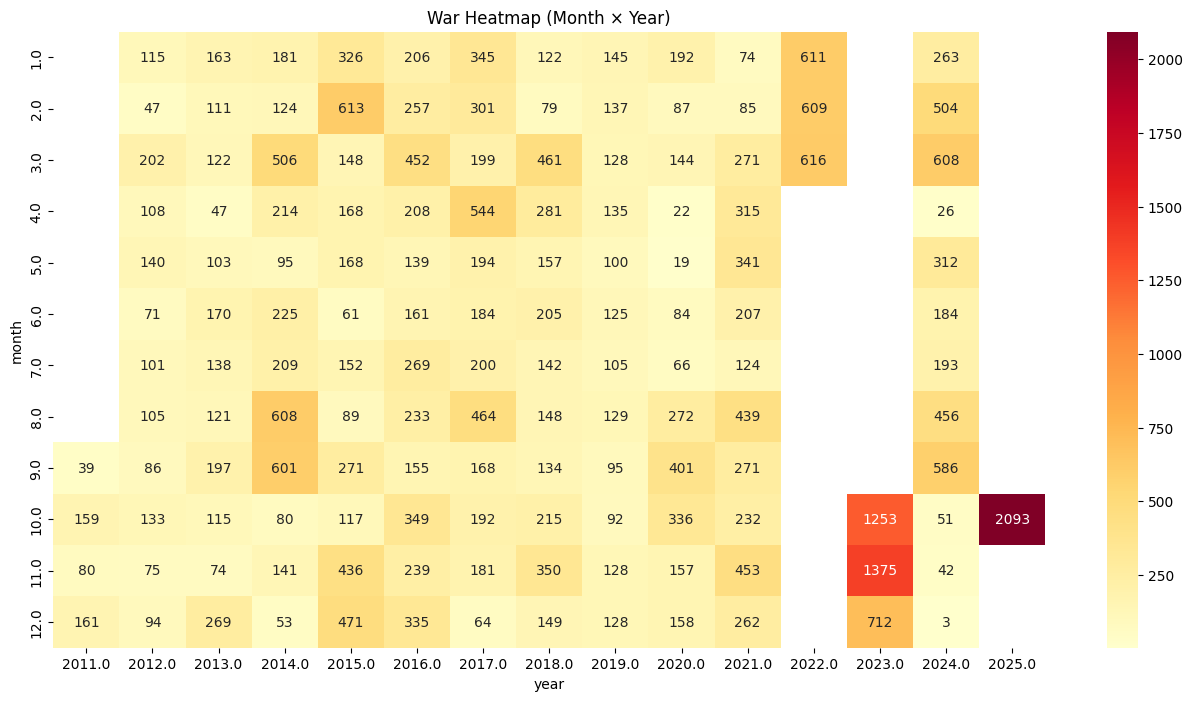

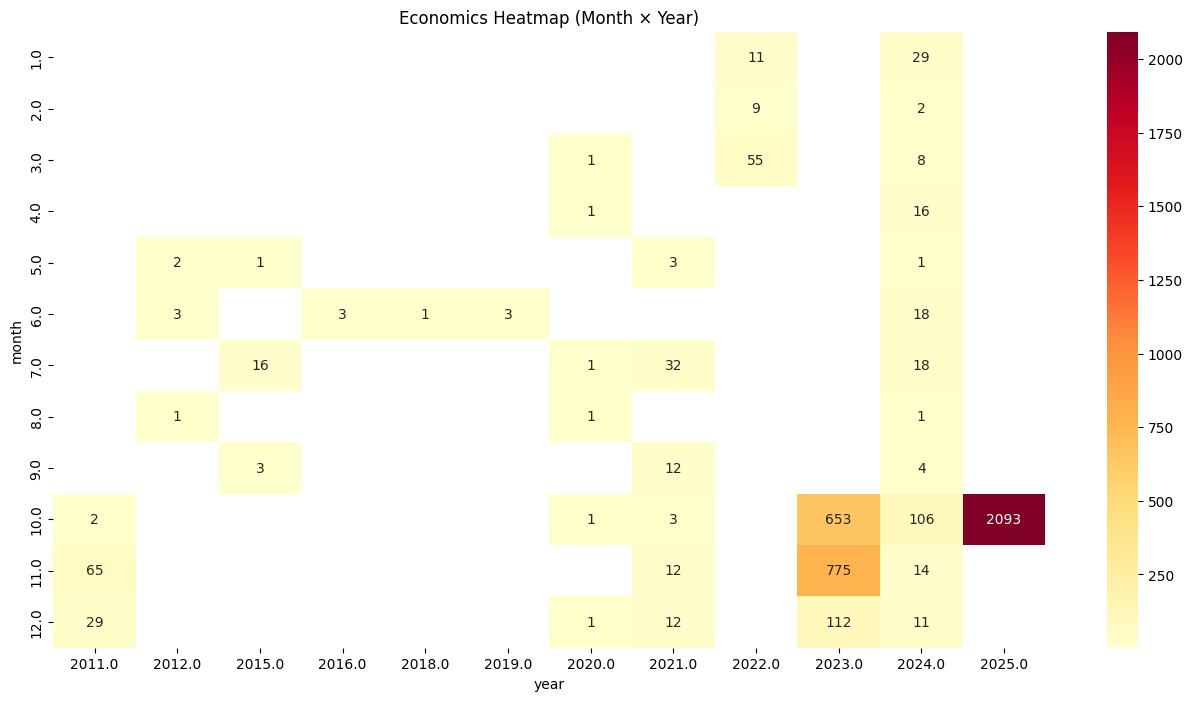

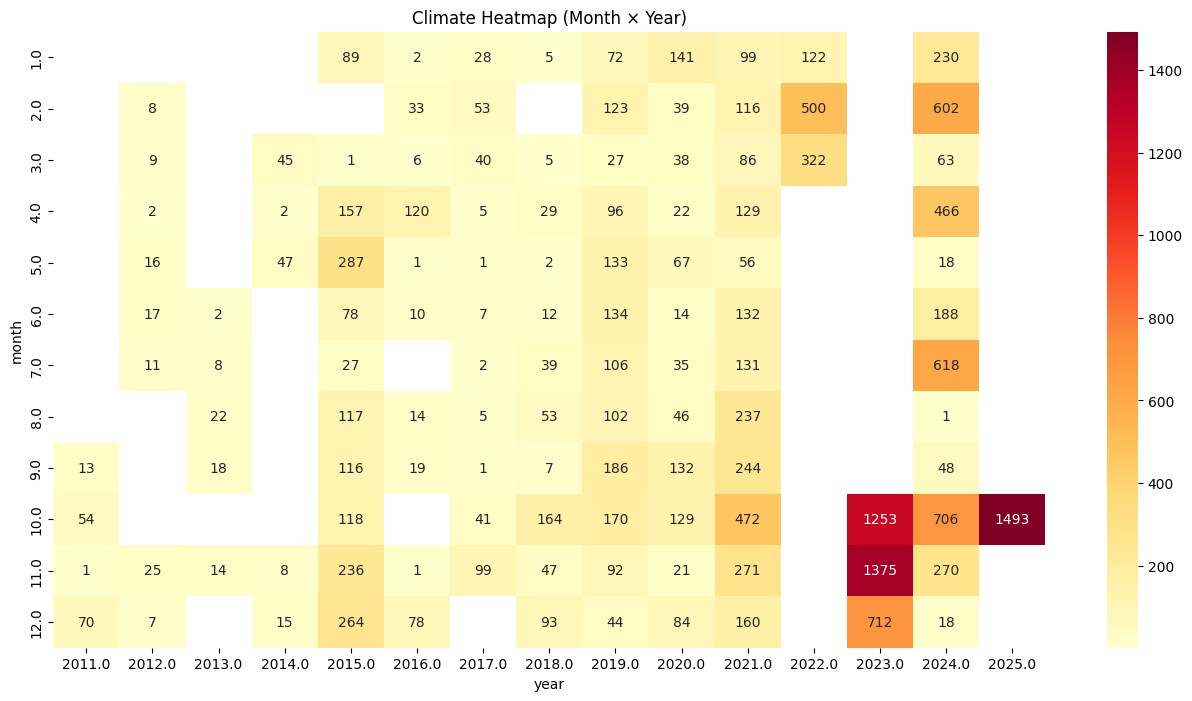

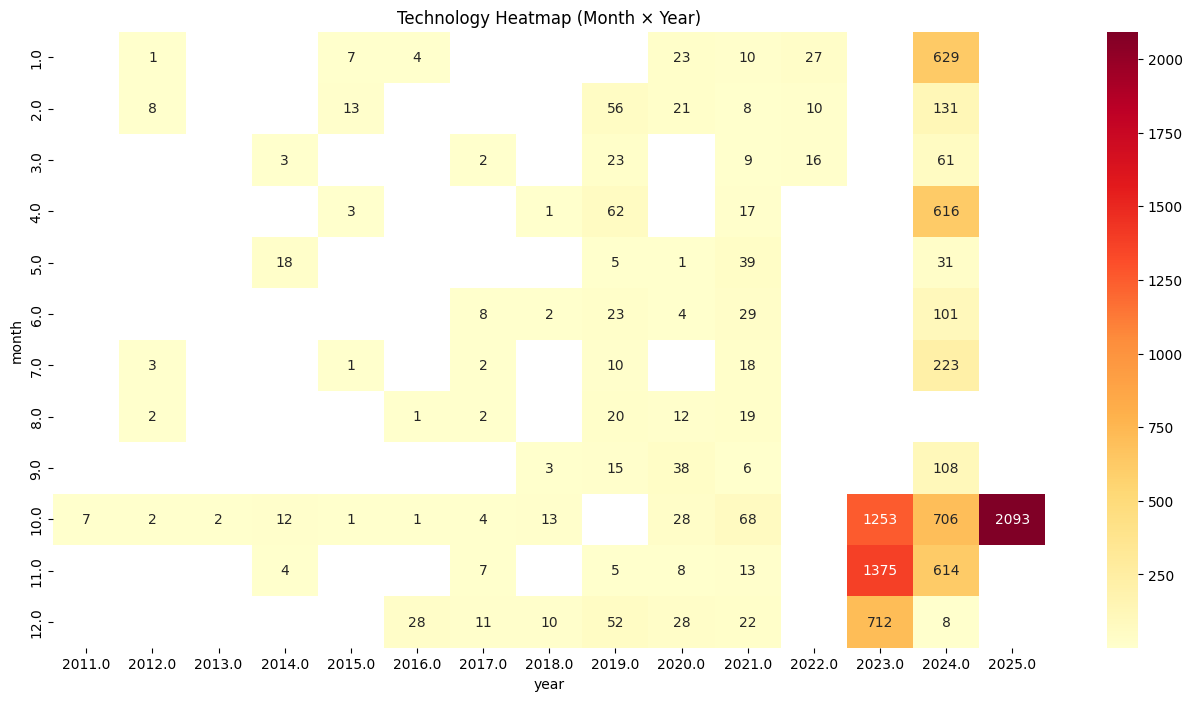

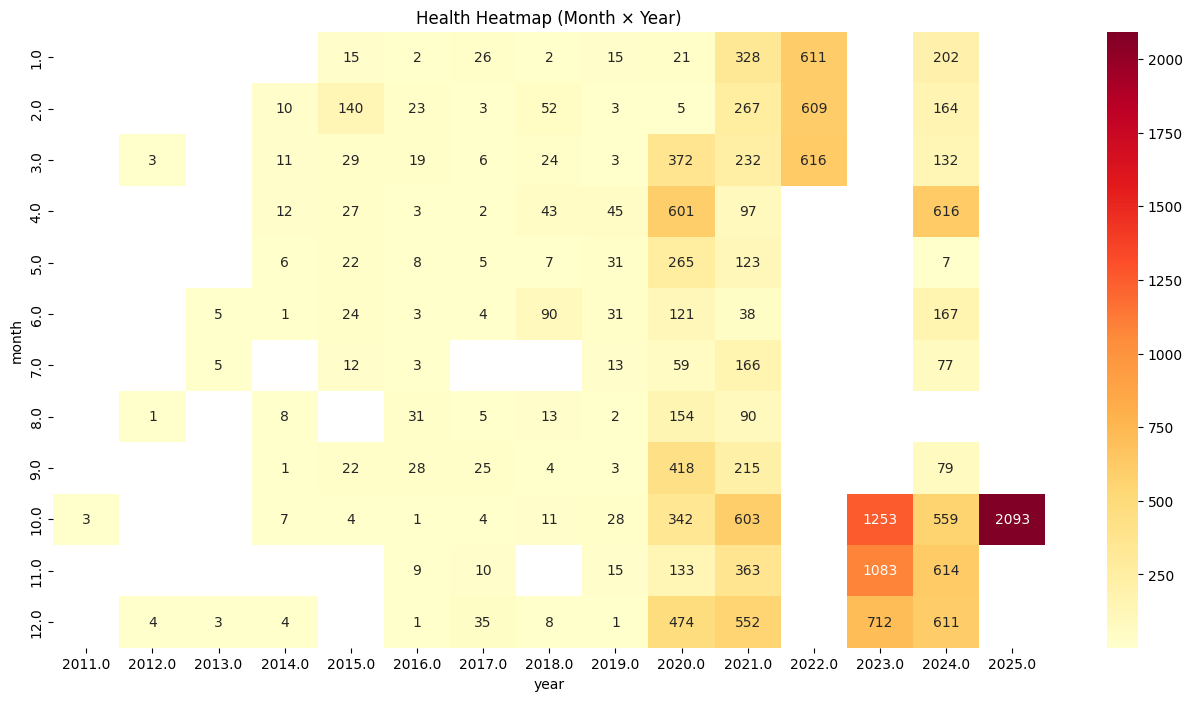

In [44]:

for topic in topics:
    
    topic_df=balanced[balanced["dominant_topic"]==topic]
    
    pivot=(
        topic_df.groupby(["year","month"])
        .size()
        .reset_index()
        .pivot(index="month",columns="year",values=0)
    )
    
    plt.figure(figsize=(16,8)) 
    
    sns.heatmap(pivot,annot=True,fmt=".0f",cmap="YlOrRd")
    
    plt.title(f"{topic} Heatmap (Month × Year)")
    
    plt.show()


In [12]:
topics = ["War","Economics","Climate","Technology","Health"]

for topic in topics:
    
    topic_df = balanced[balanced["dominant_topic"] == topic]
    
    topic_df.to_csv(f"{topic}.csv", index=False)
    
    print(topic, "rows:", len(topic_df))

War rows: 34841
Economics rows: 4145
Climate rows: 16117
Technology rows: 9592
Health rows: 17323


In [13]:
balanced.head()

,date,sentence_id,main_sentence,w5_embedding,War,Health,Technology,Climate,Economics,max_topic_weight,second_topic_weight,topic_gap,dominant_topic,year,month,year_month
1,2011-09-21 13:59:11,f1_a50_s1,Story highlightsUrsula Sladek created Germany'...,"-0.02180171,0.017887823,0.010610466,0.04336527...",0.180741,0.126097,0.217226,0.444158,0.151267,0.444158,0.217226,0.226932,Climate,2011.0,9.0,2011-09
2,2011-09-21 13:59:11,f1_a50_s2,"Founded by Sladek and a few friends in 1991, E...","-0.014108692,0.028728502,0.00976162,0.04034066...",0.210083,0.157591,0.219570,0.469669,0.150573,0.469669,0.219570,0.250099,Climate,2011.0,9.0,2011-09
3,2011-09-21 13:59:11,f1_a50_s3,"Not bad for a self-professed housewife, who wr...","-0.0099581005,0.030005964,0.00935868,0.0392172...",0.211802,0.169906,0.216497,0.472940,0.148674,0.472940,0.216497,0.256442,Climate,2011.0,9.0,2011-09
8,2011-09-21 13:59:11,f1_a50_s9,"At the time, Sladek believed that KWR, the pow...","0.020664934,0.07300932,-0.00074528955,0.012771...",0.246223,0.198027,0.172627,0.448572,0.121274,0.448572,0.246223,0.202349,Climate,2011.0,9.0,2011-09
19,2011-09-21 13:59:11,f1_a50_s20,"Collectively owned by 1,000 citizens, the comp...","-0.0026315667,0.007163382,0.018487994,0.035680...",0.076732,0.085280,0.168943,0.434365,0.097617,0.434365,0.168943,0.265422,Climate,2011.0,9.0,2011-09
